This notebook plots Fig. 3B-C, 3G-J, S4A-D, and S5A-B plots.

The notebook uses the following inputs from "5. Multiome 1 - initial processing and input preparation for Fig. 3B-C, 3G-J, S4A-D, S5A-B":
1. All-cell ArchR project (proj_all_dr)
2. Cholinergic neuron ArchR project (proj_cholinergic_dr)
3. Alpha MN ArchR project (proj_alpha)

## Setup

In [1]:
# Paths
SOD1_RENV_MULTIOME <- "/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-Multiome/"
SOD1_MULTIOME_DIR  <- "/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome"

renv::load(SOD1_RENV_MULTIOME)
Sys.setenv(SOD1_MULTIOME_DIR = SOD1_MULTIOME_DIR)

# Packages
suppressPackageStartupMessages({
  pkgs <- c(
    "ArchR", "future", "dplyr", "BSgenome.Mmusculus.UCSC.mm10",
    "pheatmap", "ggpubr", "ggrepel", "ggbreak", "cowplot",
    "Seurat", "forcats"
  )
  invisible(lapply(pkgs, library, character.only = TRUE))
})

# ArchR / future settings
addArchRGenome("mm10")
addArchRThreads(threads = 16)

plan(strategy = "multicore", workers = 16)
options(future.globals.maxSize = 41953040000)

# ArchR project paths
project_path <- function(name) file.path(SOD1_MULTIOME_DIR, name)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## All-cell plots


Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

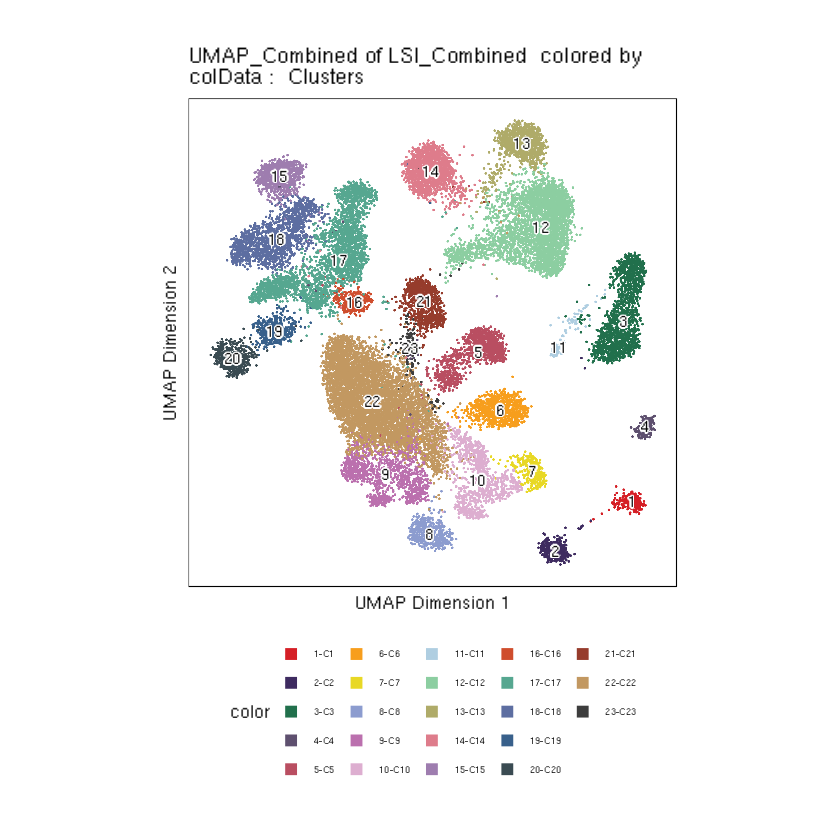

In [2]:
#Load ArchR Project
proj_all_dr <- loadArchRProject(project_path("proj_all_dr"))

all_UMAP <- plotEmbedding(proj_all_dr, name = "Clusters", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=T, labelMeans=T)
all_UMAP

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-17c52321e4a5-Date-2026-06-21_Time-23-12-11.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-06-21 23:12:11 : Matching Known Biases, 0.003 mins elapsed.

###########
2026-06-21 23:13:25 : Completed Pairwise Tests, 1.227 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-17c52321e4a5-Date-2026-06-21_Time-23-12-11.log

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-17c54c496b23-Date-2026-06-21_Time-23-13-25.log
If there is an issue, please report to github with logFile!

Identified 11 markers!



 [1] "Aqp4"    "Slc1a2"  "Atf3"    "Sox10"   "Mog"     "Slc5a7"  "Csf1r"  
 [8] "Cfap43"  "Slc32a1" "Pdgfra"  "Slc17a6"


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-17c54c496b23-Date-2026-06-21_Time-23-13-25.log



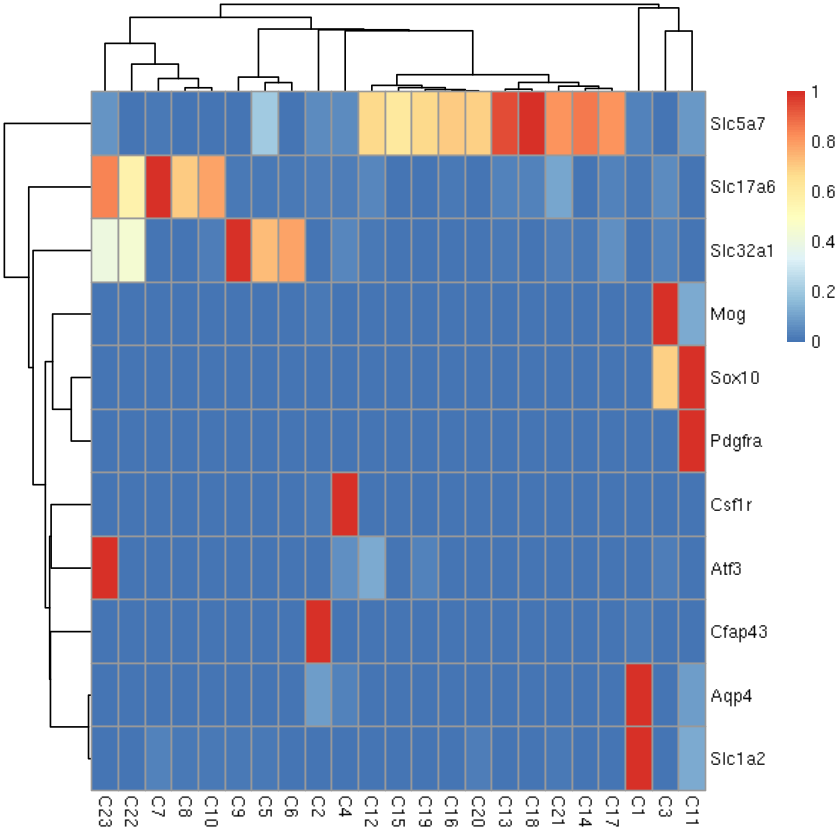

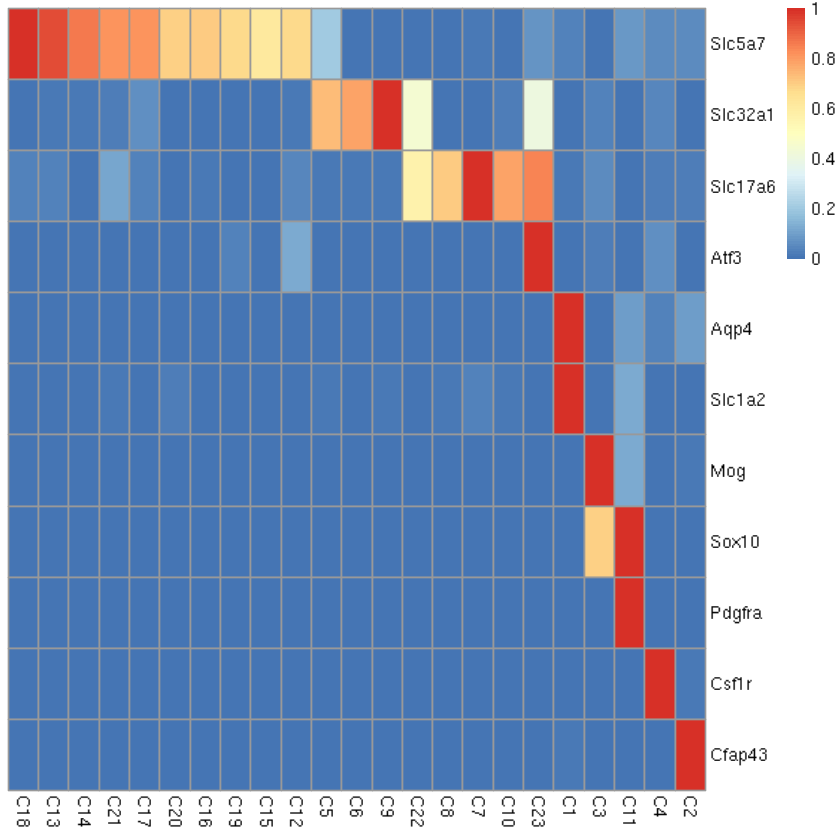

In [3]:
seGEX <- getMarkerFeatures(ArchRProj = proj_all_dr, useMatrix = "GeneExpressionMatrix")

subsetSE_GEX <- seGEX[which(rowData(seGEX)$name %in% c(
    "Slc17a6", #Excitatory
    "Slc32a1", #Inhibitory
    "Aqp4", "Slc1a2", #Astrocyte
    "Csf1r", #Microglia
    "Mog", "Sox10", #Oligodendrocyte
    "Slc5a7", #Cholinergic
    "Cfap43", #Ependymal
    "Pdgfra", #OPC
    "Atf3"  #Degenerating
  )),]

GEX_matrix <- plotMarkerHeatmap(seMarker = subsetSE_GEX, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

heatmap.avgexp <- (GEX_matrix - rowMins(GEX_matrix))/(rowMaxs(GEX_matrix) - rowMins(GEX_matrix))
pheatmap(heatmap.avgexp)

col_order <- c('C18','C13','C14','C21','C17','C20','C16','C19','C15','C12','C5','C6','C9','C22','C8','C7','C10','C23','C1','C3','C11','C4','C2')
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c('Slc5a7','Slc32a1','Slc17a6','Atf3','Aqp4','Slc1a2','Mog','Sox10','Pdgfra','Csf1r','Cfap43')
heatmap.avgexp <- heatmap.avgexp[row_order,]

pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-17c52a580d80-Date-2026-06-21_Time-23-13-26.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-17c52a580d80-Date-2026-06-21_Time-23-13-26.log



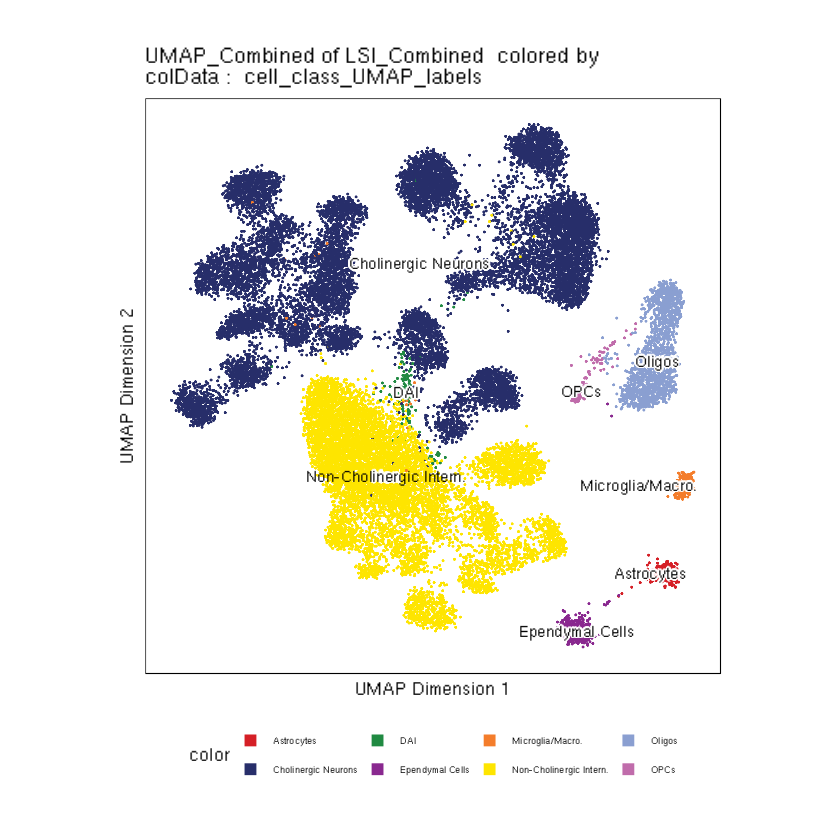

In [4]:
all_UMAP_annotated <- plotEmbedding(proj_all_dr, name = "cell_class_UMAP_labels", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=F, labelMeans=T)
all_UMAP_annotated

## Cholinergic neuron plots

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

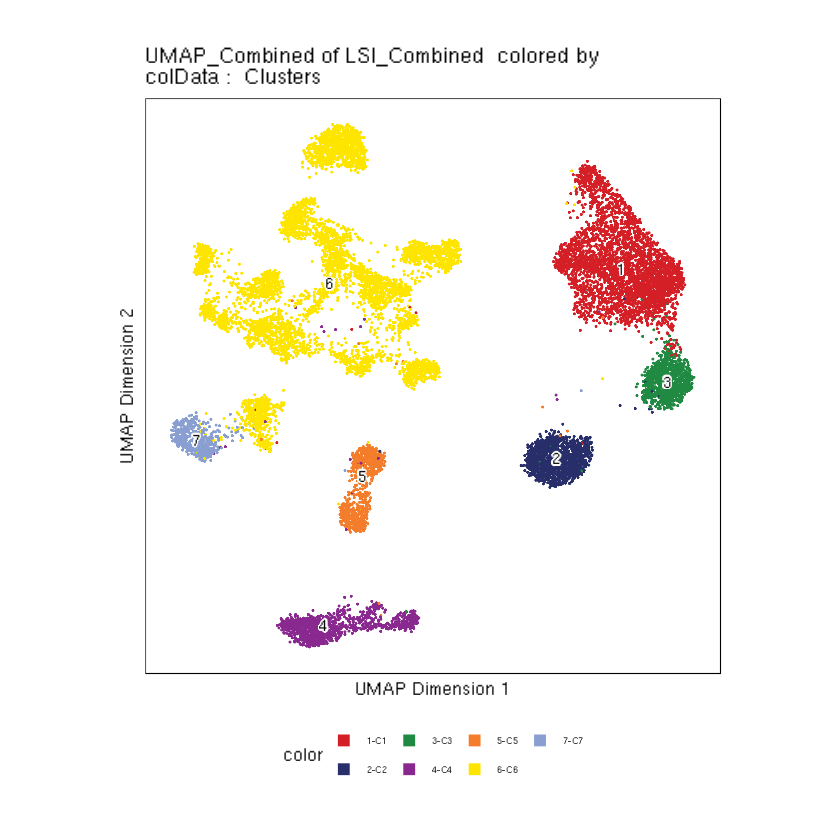

In [5]:
#Load ArchR Project
proj_cholinergic_dr <- loadArchRProject(project_path("proj_cholinergic_dr"))

cholinergic_UMAP <- plotEmbedding(proj_cholinergic_dr, name = "Clusters", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=T, labelMeans=T)
cholinergic_UMAP

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-17c51b51bfaa-Date-2026-06-21_Time-23-13-38.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-06-21 23:13:39 : Matching Known Biases, 0.002 mins elapsed.

###########
2026-06-21 23:14:04 : Completed Pairwise Tests, 0.429 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-17c51b51bfaa-Date-2026-06-21_Time-23-13-38.log

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-17c537141e43-Date-2026-06-21_Time-23-14-04.log
If there is an issue, please report to github with logFile!

Identified 11 markers!



 [1] "Mrvi1"  "Stk32a" "Plch1"  "Bcl6"   "Pard3b" "Fbn2"   "Zeb2"   "Gad1"  
 [9] "Rxfp1"  "Pitx2"  "Npas1" 


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-17c537141e43-Date-2026-06-21_Time-23-14-04.log



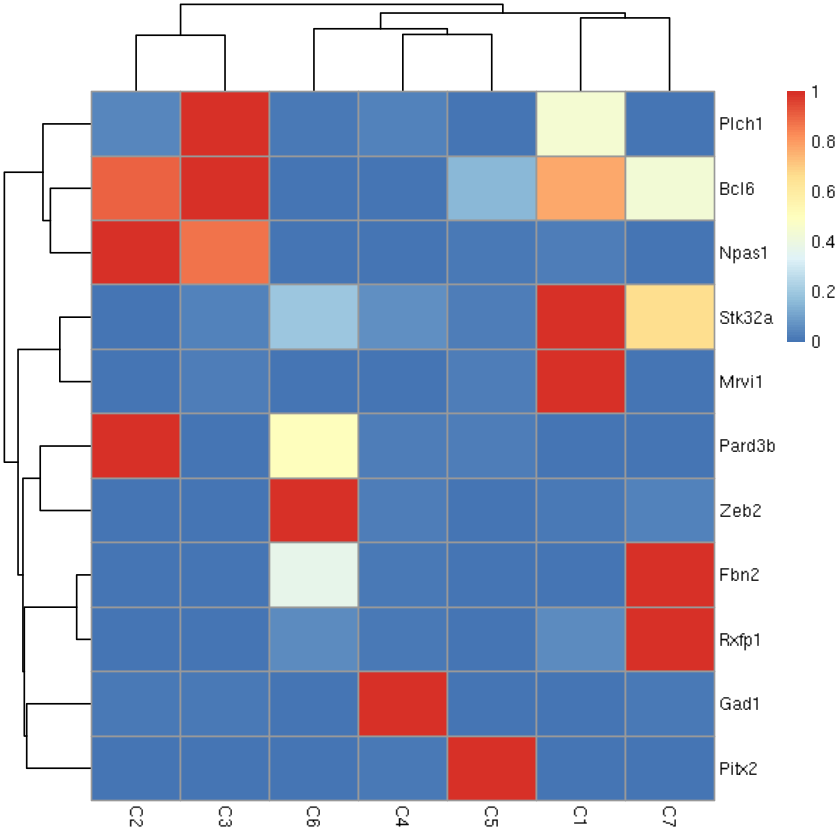

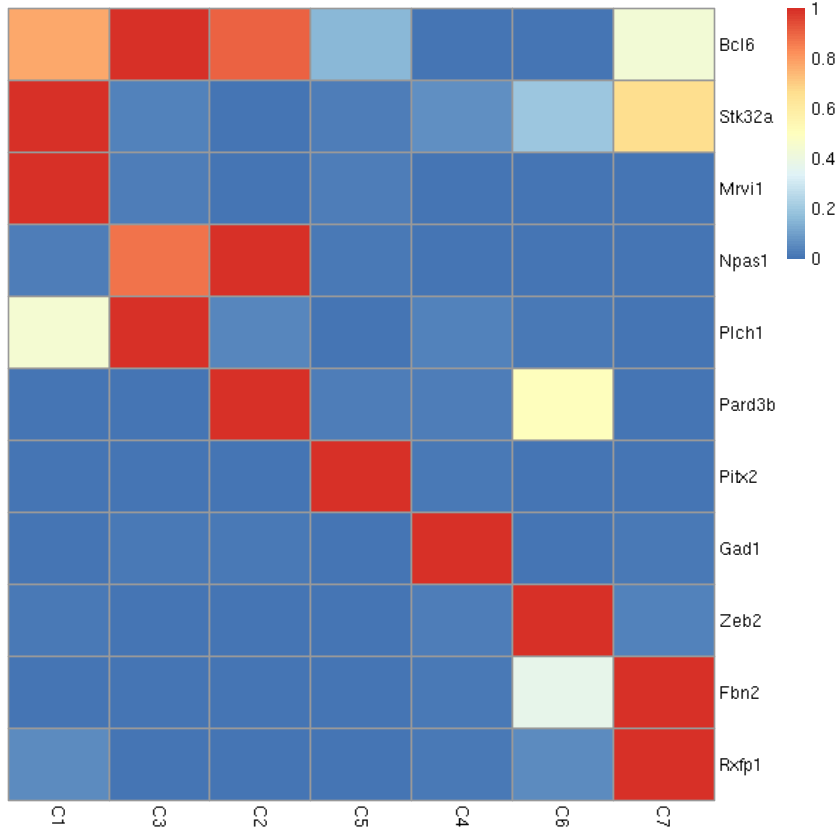

In [6]:
seGEX_cholinergic <- getMarkerFeatures(ArchRProj = proj_cholinergic_dr, useMatrix = "GeneExpressionMatrix")

subsetSE_GEX_cholinergic <- seGEX_cholinergic[which(rowData(seGEX_cholinergic)$name %in% c(
    "Bcl6", #Skeletal
    "Fbn2", "Zeb2", #Visceral
    "Rxfp1", #Sacral visceral
    "Pitx2", #Pitx2+
    "Gad1", #Inhibitory
    "Mrvi1", "Stk32a", #Alpha
    "Npas1", #Pan-gamma
    "Plch1", #Gamma*
    "Pard3b" #Gamma
  )),]

GEX_matrix_cholinergic <- plotMarkerHeatmap(seMarker = subsetSE_GEX_cholinergic, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

heatmap.avgexp_cholinergic <- (GEX_matrix_cholinergic - rowMins(GEX_matrix_cholinergic))/(rowMaxs(GEX_matrix_cholinergic) - rowMins(GEX_matrix_cholinergic))
pheatmap(heatmap.avgexp_cholinergic)

col_order <- c('C1','C3','C2','C5','C4','C6','C7')
heatmap.avgexp_cholinergic <- heatmap.avgexp_cholinergic[,col_order]

row_order <- c('Bcl6','Stk32a','Mrvi1','Npas1','Plch1','Pard3b','Pitx2','Gad1','Zeb2','Fbn2','Rxfp1')
heatmap.avgexp_cholinergic <- heatmap.avgexp_cholinergic[row_order,]

pheatmap(heatmap.avgexp_cholinergic, cluster_rows = FALSE, cluster_cols = FALSE)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-17c51567ca1f-Date-2026-06-21_Time-23-14-05.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-17c51567ca1f-Date-2026-06-21_Time-23-14-05.log



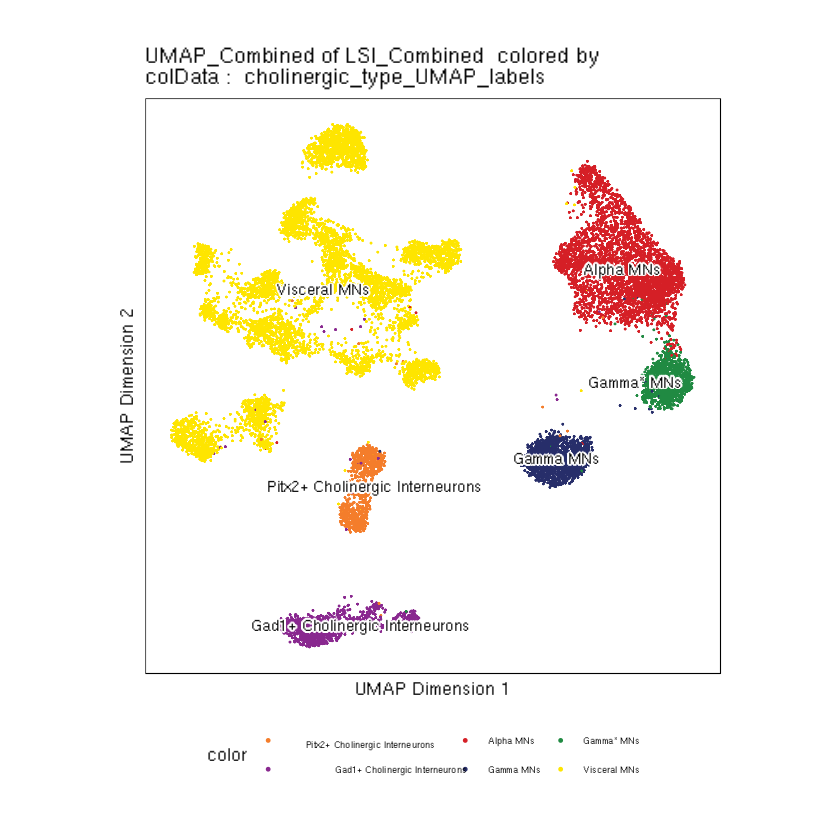

In [7]:
cholinergic_UMAP_annotated <- plotEmbedding(proj_cholinergic_dr, name = "cholinergic_type_UMAP_labels", embedding = "UMAP_Combined", pal = c('#F47D2B','#89288F','#D51F26','#272E6A','#208A42','#FEE500'), size = 0.3, labelAsFactors=F, labelMeans=T)
cholinergic_UMAP_annotated

## Alpha MN plots

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

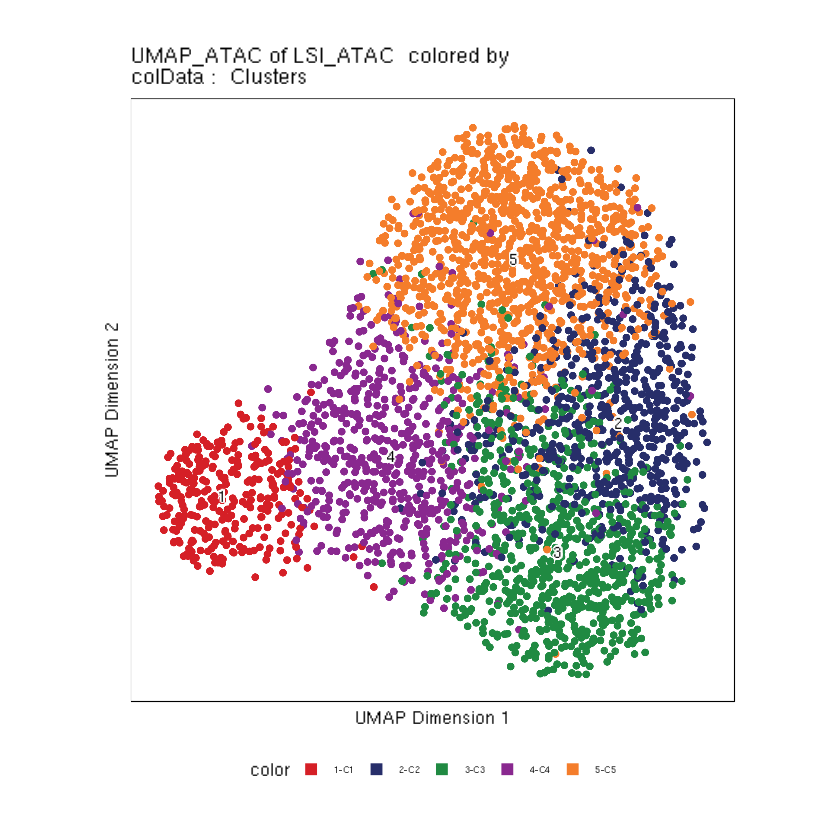

In [8]:
#Load ArchR Project
proj_alpha <- loadArchRProject(project_path("proj_alpha"))

alpha_UMAP <- plotEmbedding(proj_alpha, name = "Clusters", embedding = "UMAP_ATAC", size = 2, labelAsFactors=T, labelMeans=T)
alpha_UMAP

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-17c51e6638fc-Date-2026-06-21_Time-23-14-14.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-06-21 23:14:15 : Matching Known Biases, 0.002 mins elapsed.

###########
2026-06-21 23:14:38 : Completed Pairwise Tests, 0.386 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-17c51e6638fc-Date-2026-06-21_Time-23-14-14.log

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-17c524ea7d5b-Date-2026-06-21_Time-23-14-38.log
If there is an issue, please report to github with logFile!

Identified 8 markers!



[1] "Atf3"    "Gap43"   "Kcnq5"   "Hspa9"   "Slc7a11" "Prkcd"   "Chodl"  
[8] "Sv2a"   


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-17c524ea7d5b-Date-2026-06-21_Time-23-14-38.log



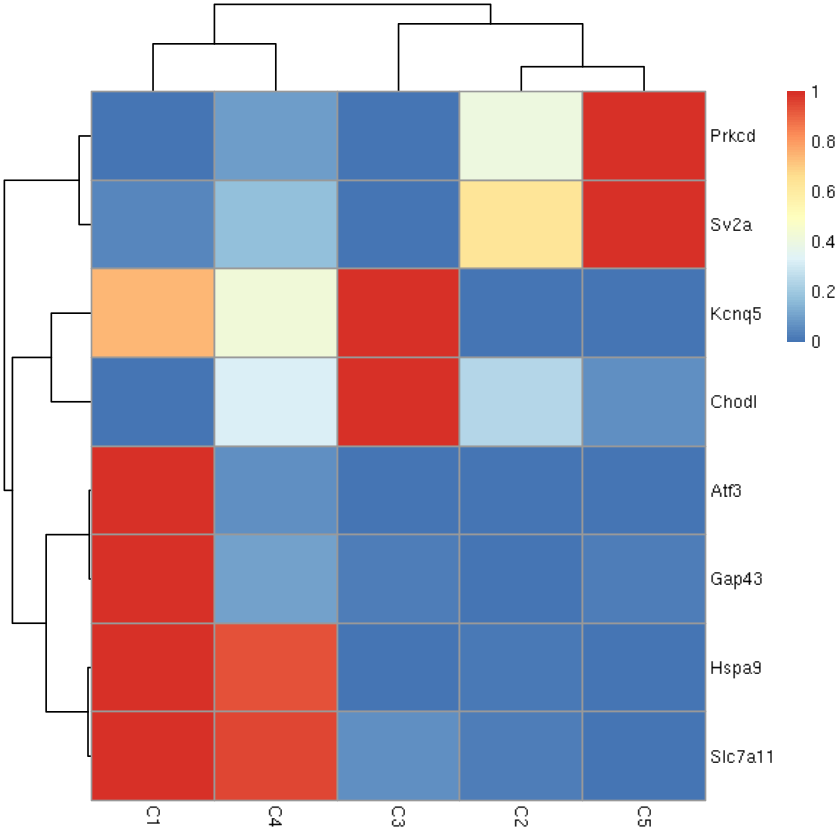

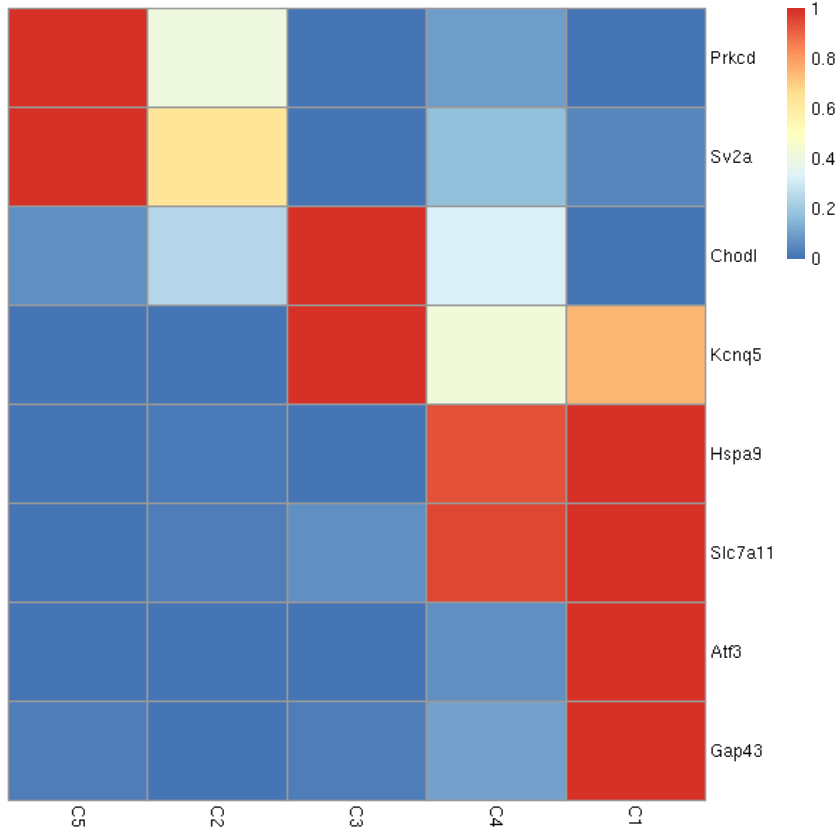

In [9]:
seGEX_alpha <- getMarkerFeatures(ArchRProj = proj_alpha, useMatrix = "GeneExpressionMatrix")

subsetSE_GEX_alpha <- seGEX_alpha[which(rowData(seGEX_alpha)$name %in% c(
    "Sv2a", "Prkcd", #Slow-firing
    "Chodl", "Kcnq5", #Fast-firing
    "Atf3", "Gap43", "Hspa9", "Slc7a11" #Degenerating
  )),]

GEX_matrix_alpha <- plotMarkerHeatmap(seMarker = subsetSE_GEX_alpha, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

heatmap.avgexp_alpha <- (GEX_matrix_alpha - rowMins(GEX_matrix_alpha))/(rowMaxs(GEX_matrix_alpha) - rowMins(GEX_matrix_alpha))
pheatmap(heatmap.avgexp_alpha)

col_order <- c('C5','C2','C3','C4','C1')
heatmap.avgexp_alpha <- heatmap.avgexp_alpha[,col_order]

row_order <- c('Prkcd','Sv2a','Chodl','Kcnq5','Hspa9','Slc7a11','Atf3','Gap43')
heatmap.avgexp_alpha <- heatmap.avgexp_alpha[row_order,]

pheatmap(heatmap.avgexp_alpha, cluster_rows = FALSE, cluster_cols = FALSE)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-17c58d7f050-Date-2026-06-21_Time-23-14-39.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-17c58d7f050-Date-2026-06-21_Time-23-14-39.log



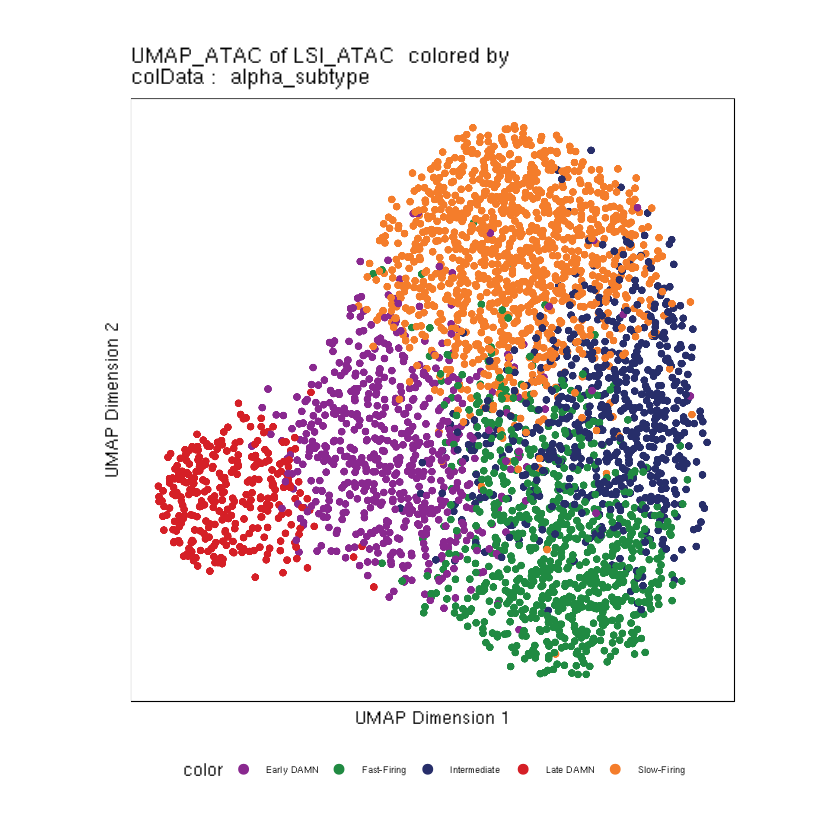

In [10]:
alpha_UMAP_add_annotations <- plotEmbedding(proj_alpha, name = "alpha_subtype", embedding = "UMAP_ATAC", pal = c('#89288F','#208A42','#272E6A','#D51F26','#F47D2B'), size = 2, labelAsFactors=F, labelMeans=F)
alpha_UMAP_add_annotations

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-17c52dbcdd04-Date-2026-06-21_Time-23-14-40.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-17c52dbcdd04-Date-2026-06-21_Time-23-14-40.log



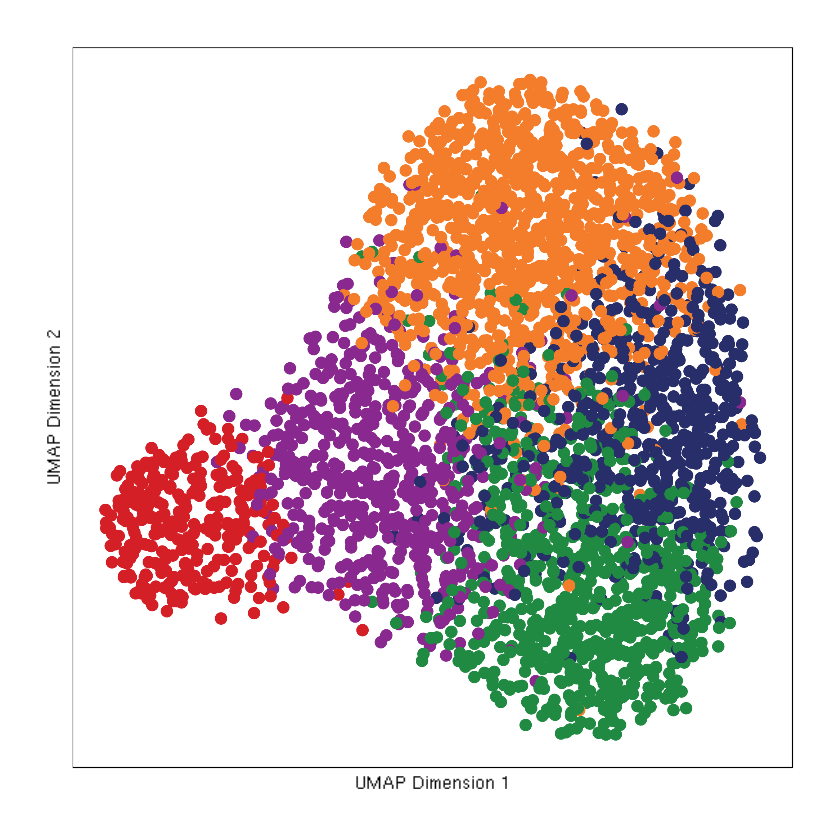

In [11]:
alpha_all_UMAP <- plotEmbedding(proj_alpha, name = "alpha_subtype", embedding = "UMAP_ATAC", pal = c('#89288F','#208A42','#272E6A','#D51F26','#F47D2B'), size = 3, labelAsFactors=F, labelMeans=F)
alpha_all_UMAP <- alpha_all_UMAP +
  theme(
    legend.position = "none",
    plot.title = element_blank()
  )

alpha_all_UMAP

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

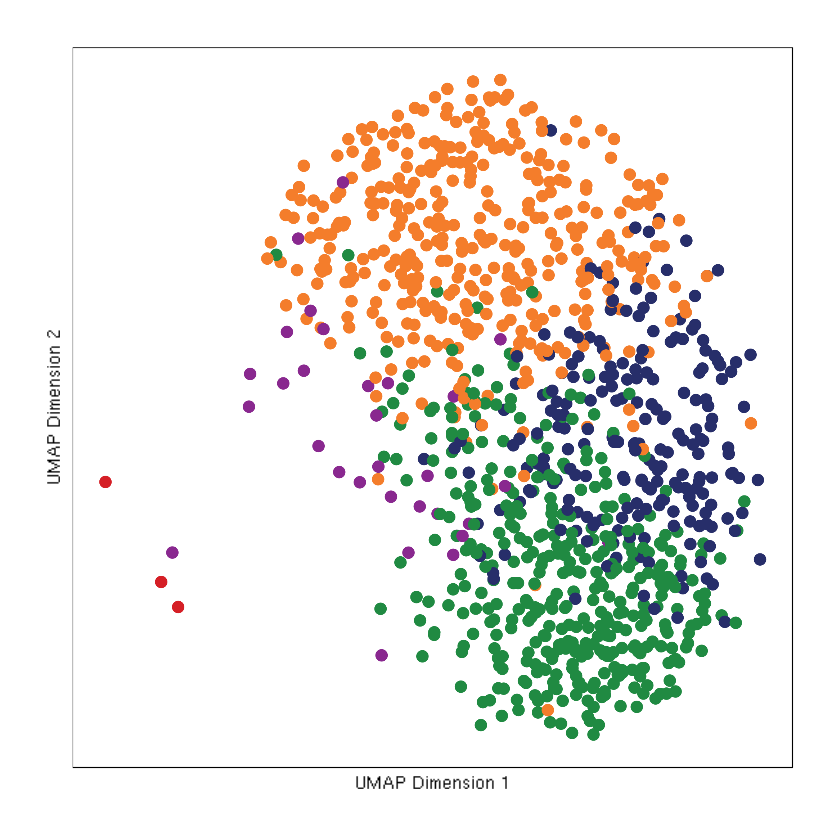

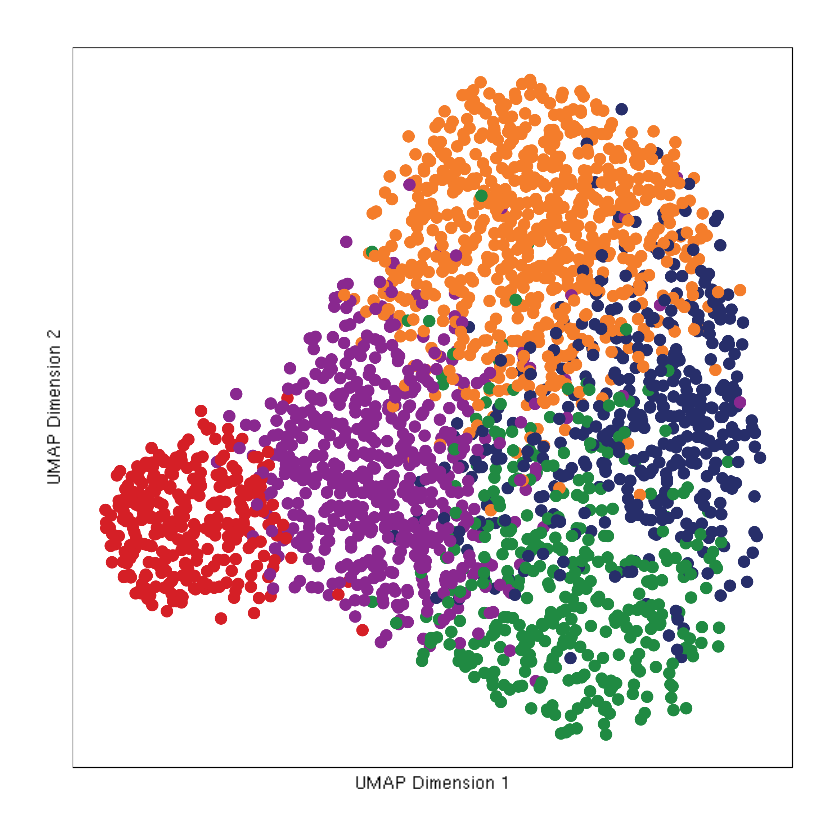

In [12]:
#Load ArchR Project
proj_alpha_control <- loadArchRProject(project_path("proj_alpha_control"))
proj_alpha_sod1 <- proj_alpha[proj_alpha$Stage %in% c('early', 'mid-late')]

alpha_control_UMAP <- plotEmbedding(proj_alpha_control, name = "alpha_subtype", embedding = "UMAP_ATAC", pal = c('#89288F','#208A42','#272E6A','#D51F26','#F47D2B'), size = 3, labelAsFactors=F, labelMeans=F)
alpha_control_UMAP <- alpha_control_UMAP +
  theme(
    legend.position = "none",
    plot.title = element_blank()
  )

alpha_control_UMAP

alpha_sod1_UMAP <- plotEmbedding(proj_alpha_sod1, name = "alpha_subtype", embedding = "UMAP_ATAC", pal = c('#89288F','#208A42','#272E6A','#D51F26','#F47D2B'), size = 3, labelAsFactors=F, labelMeans=F)
alpha_sod1_UMAP <- alpha_sod1_UMAP +
  theme(
    legend.position = "none",
    plot.title = element_blank()
  )

alpha_sod1_UMAP

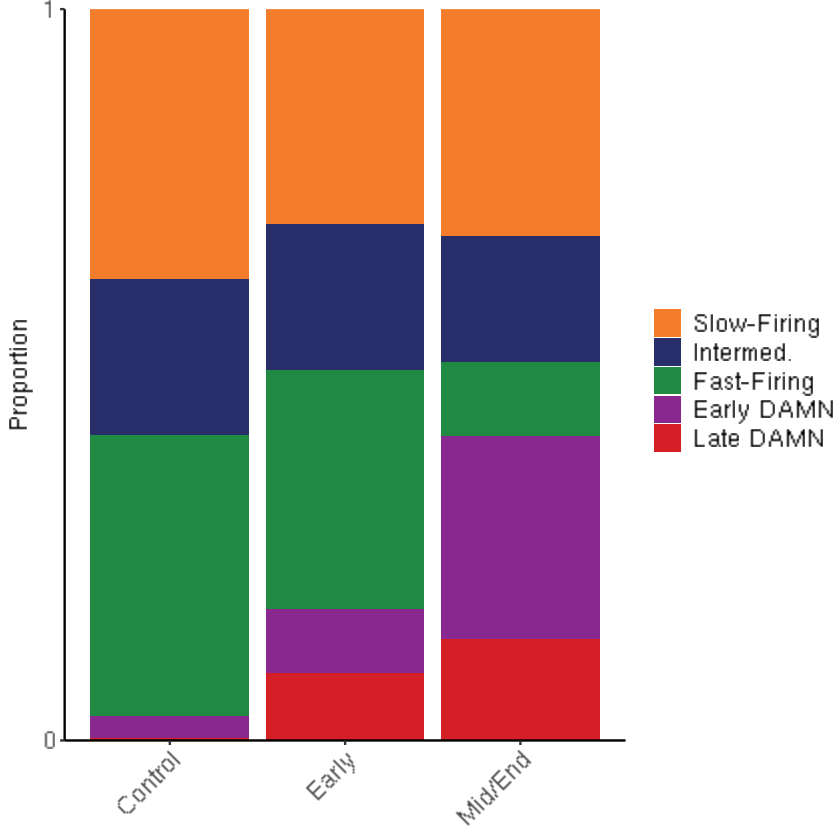

In [13]:
metadata_df <- getCellColData(proj_alpha, select = c("Sample", "Stage", "alpha_subtype")) %>% as.data.frame()

metadata_df$Stage <- factor(metadata_df$Stage, levels = c("control", "early", "mid-late"))
metadata_df$alpha_subtype <- factor(metadata_df$alpha_subtype, levels = c("Slow-Firing", "Intermediate", "Fast-Firing", "Early DAMN", "Late DAMN"))

alpha_colors <- c(
  "Slow-Firing"  = '#F47D2B',
  "Intermediate" = '#272E6A',
  "Fast-Firing"  = '#208A42',
  "Early DAMN"   = '#89288F',
  "Late DAMN"    = '#D51F26'
)

alpha_subtype_proportion <- ggplot(metadata_df, aes(x = Stage, fill = alpha_subtype)) +
  geom_bar(position = "fill") +
  scale_y_continuous(breaks = c(0, 1), expand = c(0, 0)) +
  scale_fill_manual(
    values = alpha_colors,
    labels = c('Slow-Firing', 'Intermed.', 'Fast-Firing', 'Early DAMN', 'Late DAMN')
  ) +
  scale_x_discrete(labels = c("Control", "Early", "Mid/End")) +
  ylab(expression("Proportion")) +
  theme_classic() +
  theme(
    text            = element_text(size = 14),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 14),
    axis.text.y     = element_text(size = 14),
    legend.text     = element_text(size = 14),
    axis.title.x    = element_blank(),
    legend.title    = element_blank(),
    legend.position = "right"
  )

alpha_subtype_proportion

`summarise()` has grouped output by 'Sample'. You can override using the `.groups` argument.


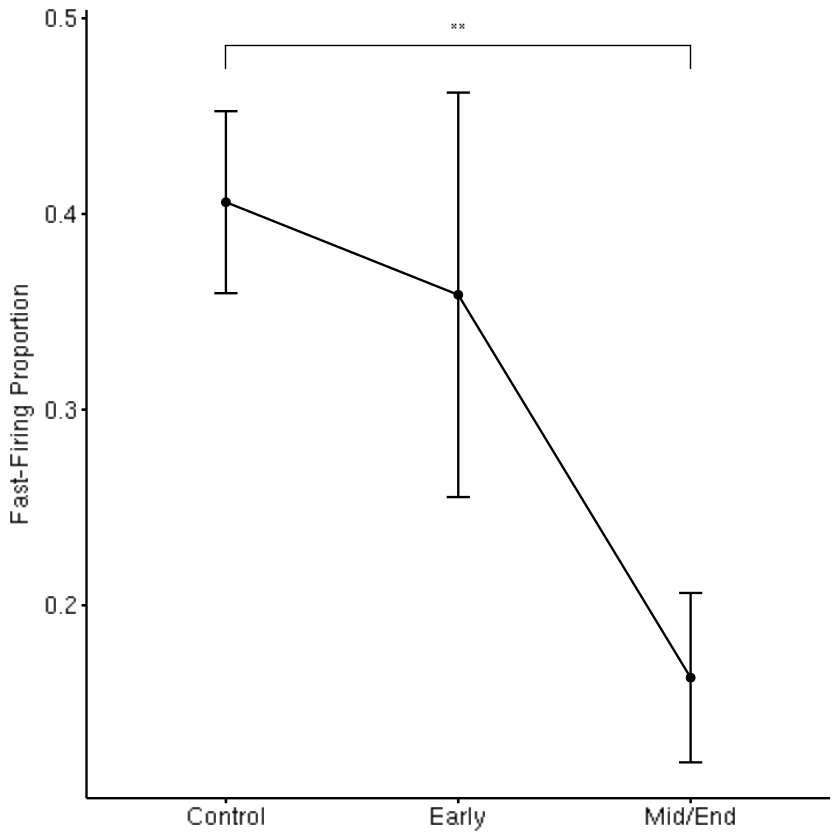

In [14]:
# Get relevant metadata
metadata_df <- getCellColData(proj_alpha, select = c("Sample", "Stage", "alpha_subtype")) %>% as.data.frame()
metadata_df_mod <- metadata_df %>% dplyr::filter(alpha_subtype %in% c("Slow-Firing", "Intermediate", "Fast-Firing"))
metadata_df_mod$FF <- ifelse(metadata_df_mod$alpha_subtype == "Fast-Firing", "Yes", "No")

# Summarize by Sample and Stage, calculate FF proportion
prop_ff_df <- metadata_df_mod %>%
  group_by(Sample, Stage) %>%
  summarise(Proportion_FF = mean(FF == "Yes"))

# Line plot of means +/- SE 
prop_ff_plot <- ggline(
  prop_ff_df,
  x = "Stage",
  y = "Proportion_FF",
  add = "mean_se"
) +
  stat_compare_means(
    comparisons = list(c("control", "mid-late")),
    label = "p.signif",
    method = "t.test",
    method.args = list(var.equal = FALSE, alternative = "greater")  # testing control > mid-late
  ) +
  scale_x_discrete(labels = c("Control", "Early", "Mid/End")) +
  ylab(expression("Fast-Firing Proportion")) +
  theme(
    text            = element_text(size = 14),
    axis.title.x    = element_blank()
  )

prop_ff_plot